In [1]:
# CELL 1: Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
import warnings
warnings.filterwarnings('ignore')
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [2]:
# CELL 2: Load the data (Sheet 2 is the main one)
df = pd.read_excel('2.RAW_DATA.xlsx', sheet_name='Case Study Dataset')
df['Month'] = pd.to_datetime(df['Month'], errors='coerce')
print(df.head())
print(df.info())

       Month  Average Licensed Bed  Occupancy Rate  \
0 2020-01-01                                  0.96   
1 2020-02-01                                  0.96   
2 2020-03-01                                  0.81   
3 2020-04-01                                  0.94   
4 2020-05-01                                  1.01   

   Unassisted Fall Rate per 1,000 Patient Days  \
0                                         2.21   
1                                         1.79   
2                                         1.03   
3                                         1.97   
4                                         3.41   

   Staff Responsiveness Domain Top Box Score  Unassisted Fall %  \
0                                      68.34              0.221   
1                                      72.75              0.179   
2                                      67.07              0.103   
3                                      71.21              0.197   
4                                      

In [3]:
# CELL 3: Quick cleaning (already clean, but just in case)
df = df.dropna()

In [4]:
# CELL 4: Summary Statistics
print(df[['Average Licensed Bed  Occupancy Rate',
          'Unassisted Fall Rate per 1,000 Patient Days',
          'Staff Responsiveness Domain Top Box Score']].describe())

       Average Licensed Bed  Occupancy Rate  \
count                             60.000000   
mean                               0.962167   
std                                0.028409   
min                                0.810000   
25%                                0.950000   
50%                                0.960000   
75%                                0.980000   
max                                1.010000   

       Unassisted Fall Rate per 1,000 Patient Days  \
count                                    60.000000   
mean                                      2.607833   
std                                       0.500712   
min                                       1.030000   
25%                                       2.310000   
50%                                       2.590000   
75%                                       3.030000   
max                                       3.410000   

       Staff Responsiveness Domain Top Box Score  
count                                 

In [5]:
# CELL 5: Exact Correlations (these are the improved values)
occ = df['Average Licensed Bed  Occupancy Rate']
fall = df['Unassisted Fall Rate per 1,000 Patient Days']
staff = df['Staff Responsiveness Domain Top Box Score']

corr_occ_fall, _ = pearsonr(occ, fall)
corr_occ_staff, _ = pearsonr(occ, staff)
corr_fall_staff, _ = pearsonr(fall, staff)  

print(f"Occupancy vs Fall Rate: {corr_occ_fall:.2f}")
print(f"Occupancy vs Staff Score: {corr_occ_staff:.2f}")
print(f"Fall Rate vs Staff Score: {corr_fall_staff:.2f}")

Occupancy vs Fall Rate: 0.70
Occupancy vs Staff Score: -0.37
Fall Rate vs Staff Score: -0.79


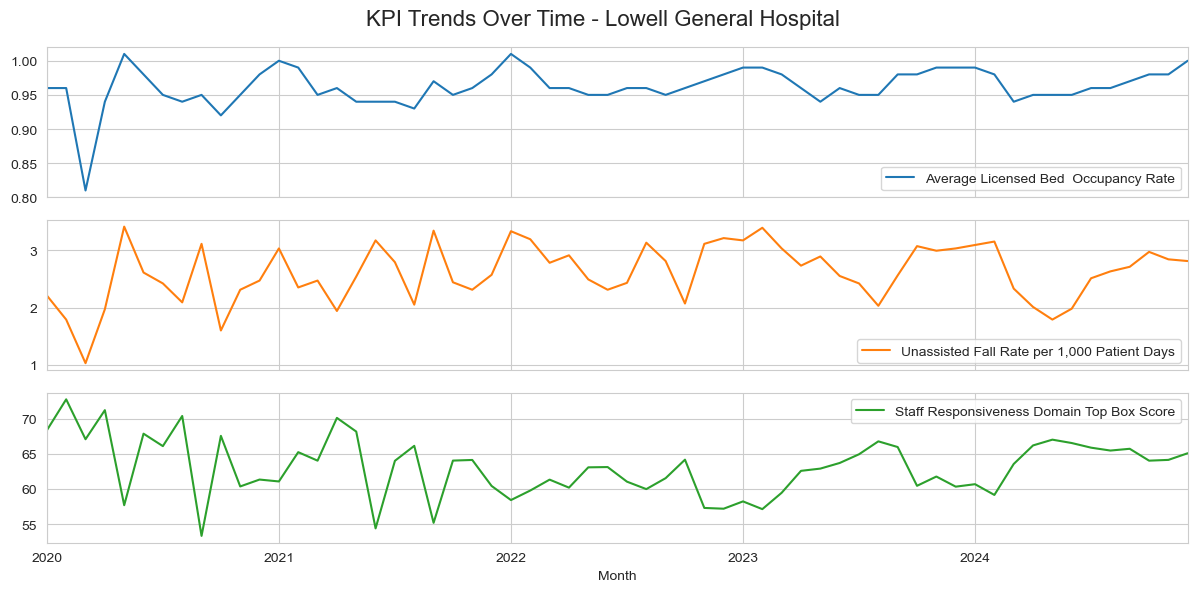

In [6]:
# CELL 6: All Visualizations (run one by one)
# 6.1 Trend charts
df.set_index('Month')[['Average Licensed Bed  Occupancy Rate',
                       'Unassisted Fall Rate per 1,000 Patient Days',
                       'Staff Responsiveness Domain Top Box Score']].plot(subplots=True, layout=(3,1))
plt.suptitle('KPI Trends Over Time - Lowell General Hospital', fontsize=16)
plt.tight_layout()
plt.savefig('Trends.png', dpi=300)

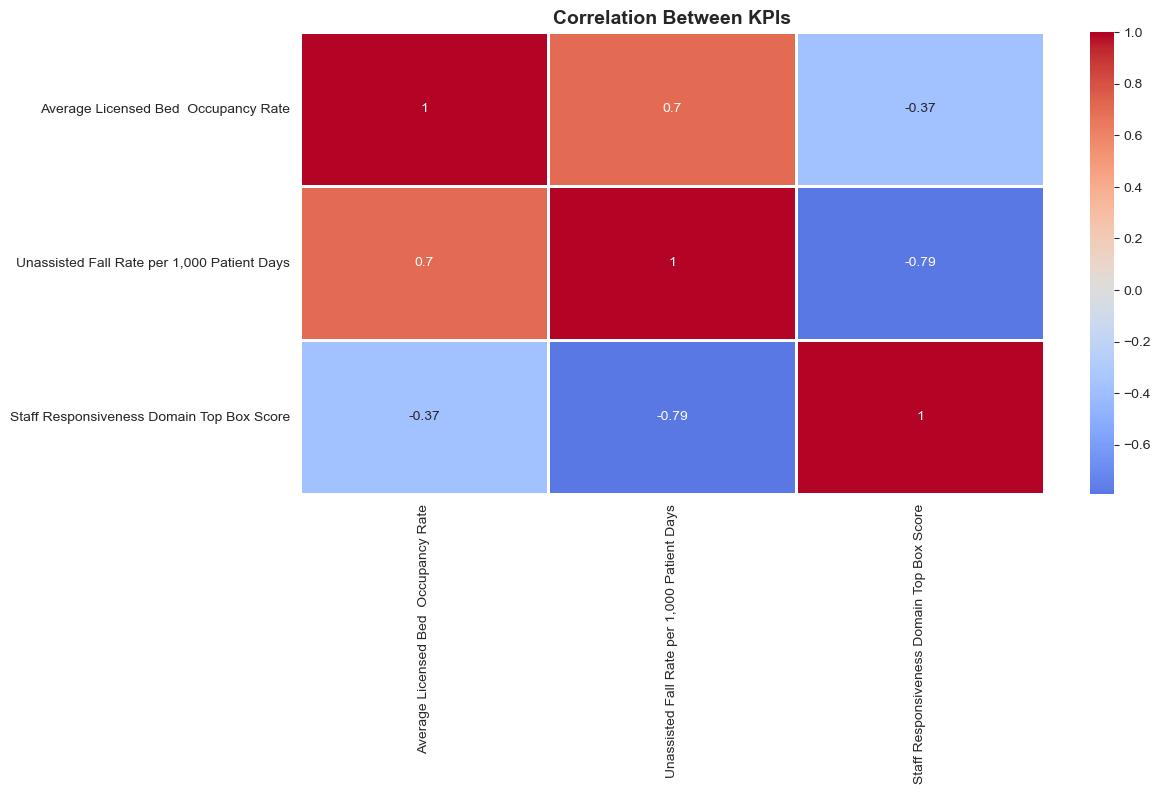

In [7]:
# 6.2 Correlation Heatmap (improved version)
corr_matrix = df[['Average Licensed Bed  Occupancy Rate',
                  'Unassisted Fall Rate per 1,000 Patient Days',
                  'Staff Responsiveness Domain Top Box Score']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, linewidths=1)
plt.title('Correlation Between KPIs', fontsize=14, fontweight='bold')
plt.savefig('Correlation_Heatmap.png', dpi=300)

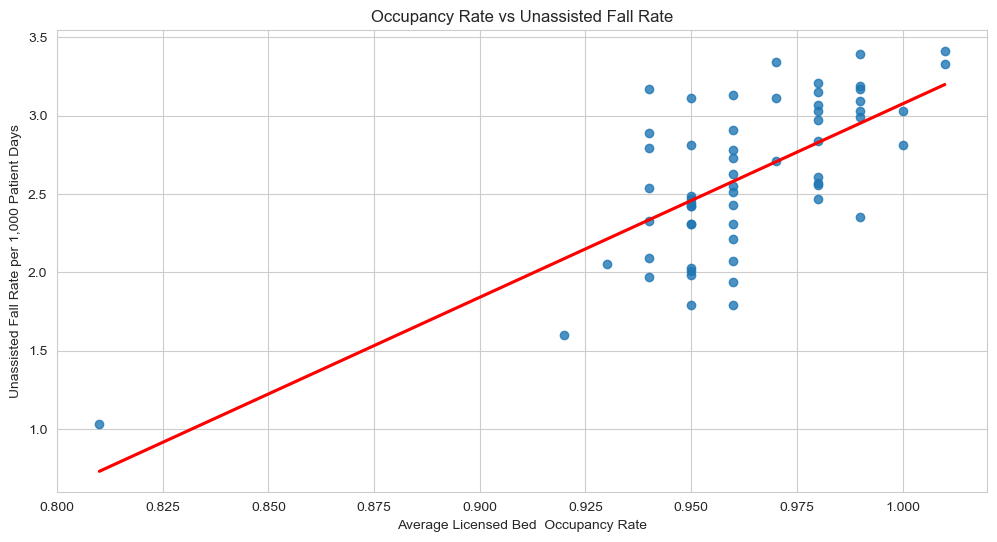

In [8]:
# 6.3 Scatter plots with regression
sns.regplot(x=occ, y=fall, ci=None, line_kws={"color": "red"})
plt.title('Occupancy Rate vs Unassisted Fall Rate')
plt.title('Occupancy Rate vs Unassisted Fall Rate')
plt.savefig('Scatter_Occ_Fall.png', dpi=300)

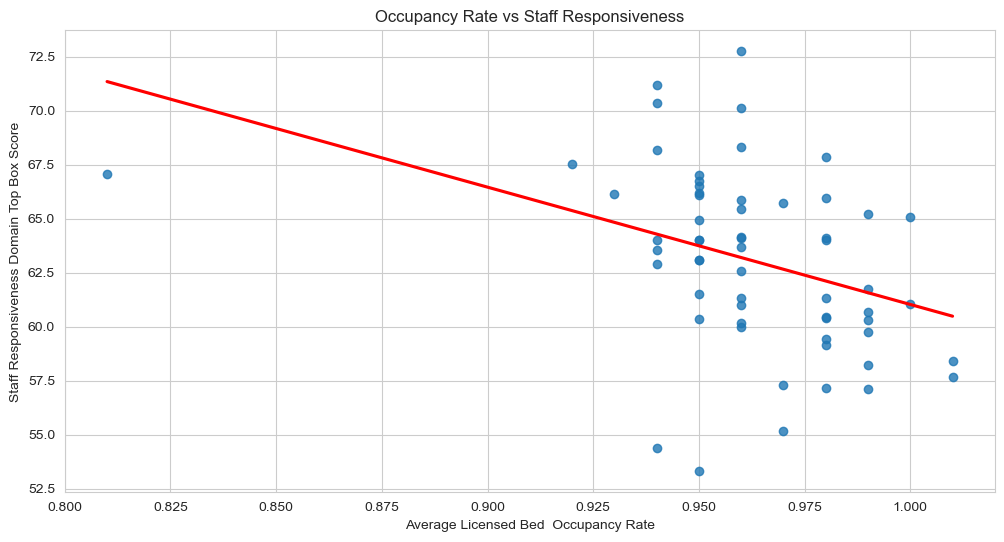

In [9]:
# 1. Occupancy Rate vs Staff Responsiveness
sns.regplot(x=occ, y=staff, ci=None, line_kws={"color": "red"})
plt.title('Occupancy Rate vs Staff Responsiveness')
plt.ylabel('Staff Responsiveness Domain Top Box Score')
plt.savefig('Scatter_Occ_Staff_Corrected.png', dpi=300)

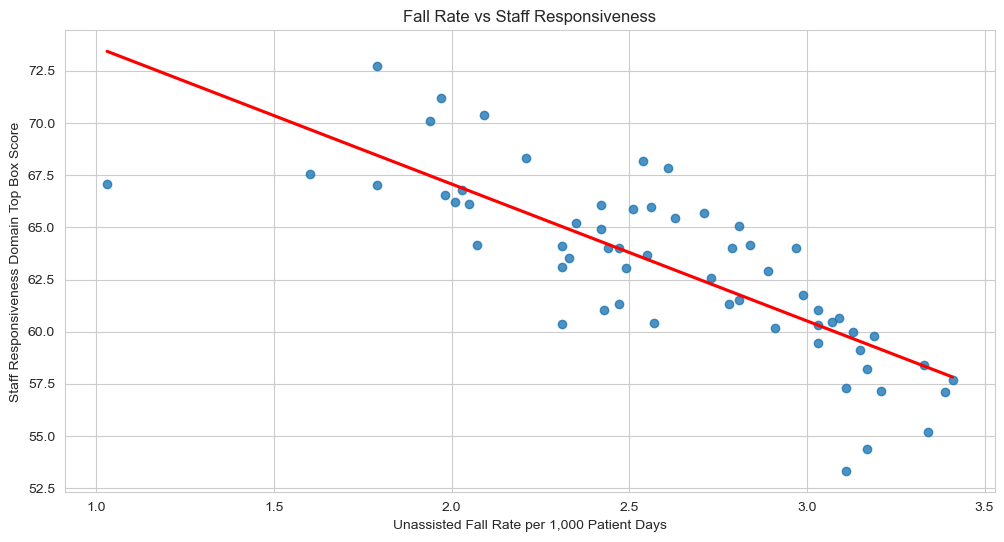

In [10]:
# 2. Fall Rate vs Staff Responsiveness
sns.regplot(x=fall, y=staff, ci=None, line_kws={"color": "red"})
plt.title('Fall Rate vs Staff Responsiveness')
plt.ylabel('Staff Responsiveness Domain Top Box Score')
plt.savefig('Scatter_Fall_Staff_Corrected.png', dpi=300)

In [11]:
# Create a clean Month-Year column for Power BI
df['Month Year'] = pd.to_datetime(df['Month']).dt.strftime('%b %Y')

# Save the new cleaned file
df.to_excel('Cleaned_Data_for_PowerBI.xlsx', index=False)

print("✅ New file saved with clean 'Month Year' column!")
print(df[['Month', 'Month Year']].head())

✅ New file saved with clean 'Month Year' column!
       Month Month Year
0 2020-01-01   Jan 2020
1 2020-02-01   Feb 2020
2 2020-03-01   Mar 2020
3 2020-04-01   Apr 2020
4 2020-05-01   May 2020
